# GPR Inversion Thesis - Step 2
## Automated Dataset Generator — 1000 (B-scan, Permittivity Map) Pairs
**Author:** Tonmoy Neog — MSc (Tech) Geophysics



## CELL 1 - Mount Drive and Install gprMax

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess
print('Installing gprMax...')
subprocess.run(['pip', 'install', '-q', 'git+https://github.com/gprMax/gprMax.git'], capture_output=True)
subprocess.run(['pip', 'install', '-q', 'h5py', 'numpy', 'matplotlib', 'scipy'], capture_output=True)
THESIS_DIR   = '/content/drive/MyDrive/GPR_Thesis'
DATASET_DIR  = f'{THESIS_DIR}/dataset'
BSCAN_DIR    = f'{DATASET_DIR}/bscans'
EPS_DIR      = f'{DATASET_DIR}/eps_maps'
META_DIR     = f'{DATASET_DIR}/metadata'
SIM_TEMP_DIR = '/content/sim_temp'
for d in [DATASET_DIR, BSCAN_DIR, EPS_DIR, META_DIR, SIM_TEMP_DIR]:
    os.makedirs(d, exist_ok=True)
print('Ready!')


Mounted at /content/drive
Installing gprMax...
Ready!


## CELL 2 - Keep-Alive (run this, then immediately run Cell 3)

In [2]:
import threading, time
keep_alive = True
def keep_colab_alive():
    while keep_alive:
        time.sleep(60)
        _ = 1 + 1
thread = threading.Thread(target=keep_colab_alive, daemon=True)
thread.start()
print('Keep-alive started. Proceed to Cell 3.')


Keep-alive started. Proceed to Cell 3.


## CELL 3 - Configuration (CHANGE N_START AND N_END EACH NIGHT)

In [3]:
import numpy as np, json

# ============================================================
# CHANGE THESE EACH NIGHT
N_START = 900    # first sample for tonight
N_END   = 1000  # last sample for tonight (exclusive)
# ============================================================

DOMAIN_X    = 0.60
DOMAIN_Z    = 0.40
GRID_SIZE   = 0.002
CENTER_FREQ = 900e6
N_TRACES    = 100
TRACE_STEP  = 0.005
ANT_START_X = 0.02
ANT_OFFSET  = 0.002
TIME_WINDOW = 8e-9
TOTAL_SAMPLES = 1000

PIPE_TYPES = [
    ('air',   1.0,  0.0),
    ('water', 81.0, 0.01),
    ('pvc',   3.0,  0.0),
    ('layer', None, None),
]

np.random.seed(42)
all_params = []
for i in range(TOTAL_SAMPLES):
    pipe_name, pipe_eps, pipe_cond = PIPE_TYPES[i % 4]
    all_params.append({
        'sample_id':    i,
        'pipe_type':    pipe_name,
        'pipe_eps':     pipe_eps,
        'pipe_cond':    pipe_cond,
        'pipe_x':       round(np.random.uniform(0.10, 0.50), 4),
        'pipe_z':       round(np.random.uniform(0.05, 0.28), 4),
        'pipe_r':       round(np.random.uniform(0.01, 0.05), 4),
        'soil_eps':     round(np.random.uniform(4.0, 15.0), 2),
        'soil_cond':    round(np.random.uniform(0.0001, 0.005), 6),
        'layer2_eps':   round(np.random.uniform(10.0, 25.0), 2),
        'layer2_depth': round(np.random.uniform(0.15, 0.30), 4),
    })

with open(f'{DATASET_DIR}/all_params.json', 'w') as f:
    json.dump(all_params, f, indent=2)

print(f'Total samples:    {TOTAL_SAMPLES}')
print(f'Tonight:          {N_START} to {N_END-1}')
print(f'Estimated time:   ~{(N_END-N_START)*110/3600:.1f} hours')
print(f'Parameter file saved to Drive.')


Total samples:    1000
Tonight:          900 to 999
Estimated time:   ~3.1 hours
Parameter file saved to Drive.


## CELL 4 - Helper Functions

In [4]:
import h5py, numpy as np, subprocess, os, shutil
from scipy.ndimage import zoom

def generate_input_file(params, sim_dir):
    sid = params['sample_id']
    fname = f'{sim_dir}/sim_{sid:04d}.in'
    soil_line = f"#material: {params['soil_eps']} {params['soil_cond']} 1.0 0.0 soil_{sid}"
    box_line  = f"#box: 0 0 0 {DOMAIN_X} {DOMAIN_Z} {GRID_SIZE} soil_{sid}"
    if params['pipe_type'] == 'layer':
        d2 = params['layer2_depth']
        extra = (f"#material: {params['layer2_eps']} {params['soil_cond']} 1.0 0.0 soil2_{sid}\n"
                 f"#box: 0 {d2} 0 {DOMAIN_X} {DOMAIN_Z} {GRID_SIZE} soil2_{sid}")
        pipe_mat = 'free_space'
    elif params['pipe_type'] == 'air':
        extra = ''
        pipe_mat = 'free_space'
    else:
        extra = f"#material: {params['pipe_eps']} {params['pipe_cond']} 1.0 0.0 pipe_{sid}"
        pipe_mat = f'pipe_{sid}'
    cyl = (f"#cylinder: {params['pipe_x']} {params['pipe_z']} 0 "
           f"{params['pipe_x']} {params['pipe_z']} {GRID_SIZE} "
           f"{params['pipe_r']} {pipe_mat}")
    content = f"""#title: Sample_{sid:04d}
#domain: {DOMAIN_X} {DOMAIN_Z} {GRID_SIZE}
#dx_dy_dz: {GRID_SIZE} {GRID_SIZE} {GRID_SIZE}
#time_window: {TIME_WINDOW}
{soil_line}
{box_line}
{extra}
{cyl}
#waveform: ricker 1.0 {CENTER_FREQ} src_{sid}
#hertzian_dipole: z {ANT_START_X} {GRID_SIZE} 0 src_{sid}
#rx: {ANT_START_X + ANT_OFFSET} {GRID_SIZE} 0
#src_steps: {TRACE_STEP} 0 0
#rx_steps: {TRACE_STEP} 0 0
"""
    with open(fname, 'w') as f:
        f.write(content)
    return fname

def run_simulation(input_file, n_traces):
    result = subprocess.run(
        ['python', '-m', 'gprMax', input_file, '-n', str(n_traces)],
        capture_output=True, text=True)
    return result.returncode == 0

def extract_bscan(sim_dir, base_name, n_traces):
    traces = []
    for i in range(1, n_traces + 1):
        fpath = f'{sim_dir}/{base_name}{i}.out'
        if not os.path.exists(fpath):
            return None
        with h5py.File(fpath, 'r') as f:
            try:
                trace = np.array(f['rxs/rx1/Ez'])
            except KeyError:
                trace = np.array(f['rxs/rx1/Ex'])
        traces.append(trace)
    return np.column_stack(traces)

def generate_eps_map(params):
    NZ = int(DOMAIN_Z / GRID_SIZE)
    NX = int(DOMAIN_X / GRID_SIZE)
    eps_map = np.ones((NZ, NX), dtype=np.float32) * params['soil_eps']
    if params['pipe_type'] == 'layer':
        ls = int(params['layer2_depth'] / GRID_SIZE)
        eps_map[ls:, :] = params['layer2_eps']
    pipe_ix = int(params['pipe_x'] / GRID_SIZE)
    pipe_iz = int(params['pipe_z'] / GRID_SIZE)
    pipe_ir = int(params['pipe_r'] / GRID_SIZE)
    for iz in range(max(0, pipe_iz-pipe_ir-2), min(NZ, pipe_iz+pipe_ir+2)):
        for ix in range(max(0, pipe_ix-pipe_ir-2), min(NX, pipe_ix+pipe_ir+2)):
            if np.sqrt((ix-pipe_ix)**2 + (iz-pipe_iz)**2) <= pipe_ir:
                if params['pipe_type'] in ('air', 'layer'):
                    eps_map[iz, ix] = 1.0
                elif params['pipe_type'] == 'water':
                    eps_map[iz, ix] = 81.0
                elif params['pipe_type'] == 'pvc':
                    eps_map[iz, ix] = 3.0
    return zoom(eps_map, (200/NZ, 100/NX), order=0).astype(np.float32)

def preprocess_bscan(bscan):
    bscan_br = bscan - np.mean(bscan, axis=1, keepdims=True)
    if bscan_br.shape[0] != 512:
        bscan_br = zoom(bscan_br, (512/bscan_br.shape[0], 1.0), order=1)
    mx = np.abs(bscan_br).max()
    if mx > 0:
        bscan_br = bscan_br / mx
    return bscan_br.astype(np.float32)

def cleanup_sim_files(sim_dir, base_name, n_traces):
    for i in range(1, n_traces + 1):
        for fpath in [f'{sim_dir}/{base_name}{i}.out', f'{sim_dir}/{base_name}.in']:
            if os.path.exists(fpath):
                os.remove(fpath)

def is_completed(sample_id):
    return (os.path.exists(f'{BSCAN_DIR}/bscan_{sample_id:04d}.npy') and
            os.path.exists(f'{EPS_DIR}/eps_{sample_id:04d}.npy'))

print('All helper functions ready.')


All helper functions ready.


## CELL 5 - Check Progress

In [5]:
completed = [i for i in range(TOTAL_SAMPLES) if is_completed(i)]
tonight   = [i for i in range(N_START, N_END) if not is_completed(i)]
print(f'Already completed: {len(completed)}/{TOTAL_SAMPLES}')
print(f'To run tonight:    {len(tonight)}')
print(f'Estimated time:    ~{len(tonight)*110/3600:.1f} hours')


Already completed: 1000/1000
To run tonight:    0
Estimated time:    ~0.0 hours


## CELL 6 - Run Dataset Generation (Main Loop)

In [6]:
import time, json

print(f'Starting: samples {N_START} to {N_END-1}')
print('-' * 55)
session_start  = time.time()
session_count  = 0
session_failed = []

for sample_id in range(N_START, N_END):
    if is_completed(sample_id):
        continue
    params    = all_params[sample_id]
    sim_start = time.time()
    base_name = f'sim_{sample_id:04d}'
    try:
        input_file = generate_input_file(params, SIM_TEMP_DIR)
        if not run_simulation(input_file, N_TRACES):
            session_failed.append(sample_id)
            continue
        bscan_raw = extract_bscan(SIM_TEMP_DIR, base_name, N_TRACES)
        if bscan_raw is None:
            session_failed.append(sample_id)
            continue
        bscan_proc = preprocess_bscan(bscan_raw)
        eps_map    = generate_eps_map(params)
        np.save(f'{BSCAN_DIR}/bscan_{sample_id:04d}.npy', bscan_proc)
        np.save(f'{EPS_DIR}/eps_{sample_id:04d}.npy', eps_map)
        with open(f'{META_DIR}/meta_{sample_id:04d}.json', 'w') as mf:
            json.dump(params, mf)
        cleanup_sim_files(SIM_TEMP_DIR, base_name, N_TRACES)
        session_count += 1
        if session_count % 10 == 0 or session_count == 1:
            elapsed  = time.time() - session_start
            avg_time = elapsed / session_count
            eta_h    = ((N_END - N_START - session_count) * avg_time) / 3600
            total_done = sum(1 for i in range(TOTAL_SAMPLES) if is_completed(i))
            print(f'[{sample_id:4d}] type={params["pipe_type"]:6s} | '
                  f't={time.time()-sim_start:.0f}s | '
                  f'tonight={session_count}/{N_END-N_START} | '
                  f'total={total_done}/{TOTAL_SAMPLES} | '
                  f'ETA={eta_h:.1f}h')
    except Exception as e:
        print(f'[{sample_id:4d}] ERROR: {str(e)[:80]}')
        session_failed.append(sample_id)
        try:
            cleanup_sim_files(SIM_TEMP_DIR, base_name, N_TRACES)
        except:
            pass

total_done = sum(1 for i in range(TOTAL_SAMPLES) if is_completed(i))
print()
print('=' * 55)
print('SESSION COMPLETE')
print('=' * 55)
print(f'Run this session:   {session_count}')
print(f'Failed:             {len(session_failed)}')
print(f'Total progress:     {total_done}/{TOTAL_SAMPLES}')
print(f'Time:               {(time.time()-session_start)/3600:.2f} hours')
if session_failed:
    print(f'Failed IDs:         {session_failed}')
print('Tomorrow: change N_START and N_END in Cell 3 and rerun.')


Starting: samples 900 to 999
-------------------------------------------------------

SESSION COMPLETE
Run this session:   0
Failed:             0
Total progress:     1000/1000
Time:               0.00 hours
Tomorrow: change N_START and N_END in Cell 3 and rerun.


## CELL 7 - Verify and Visualize Samples

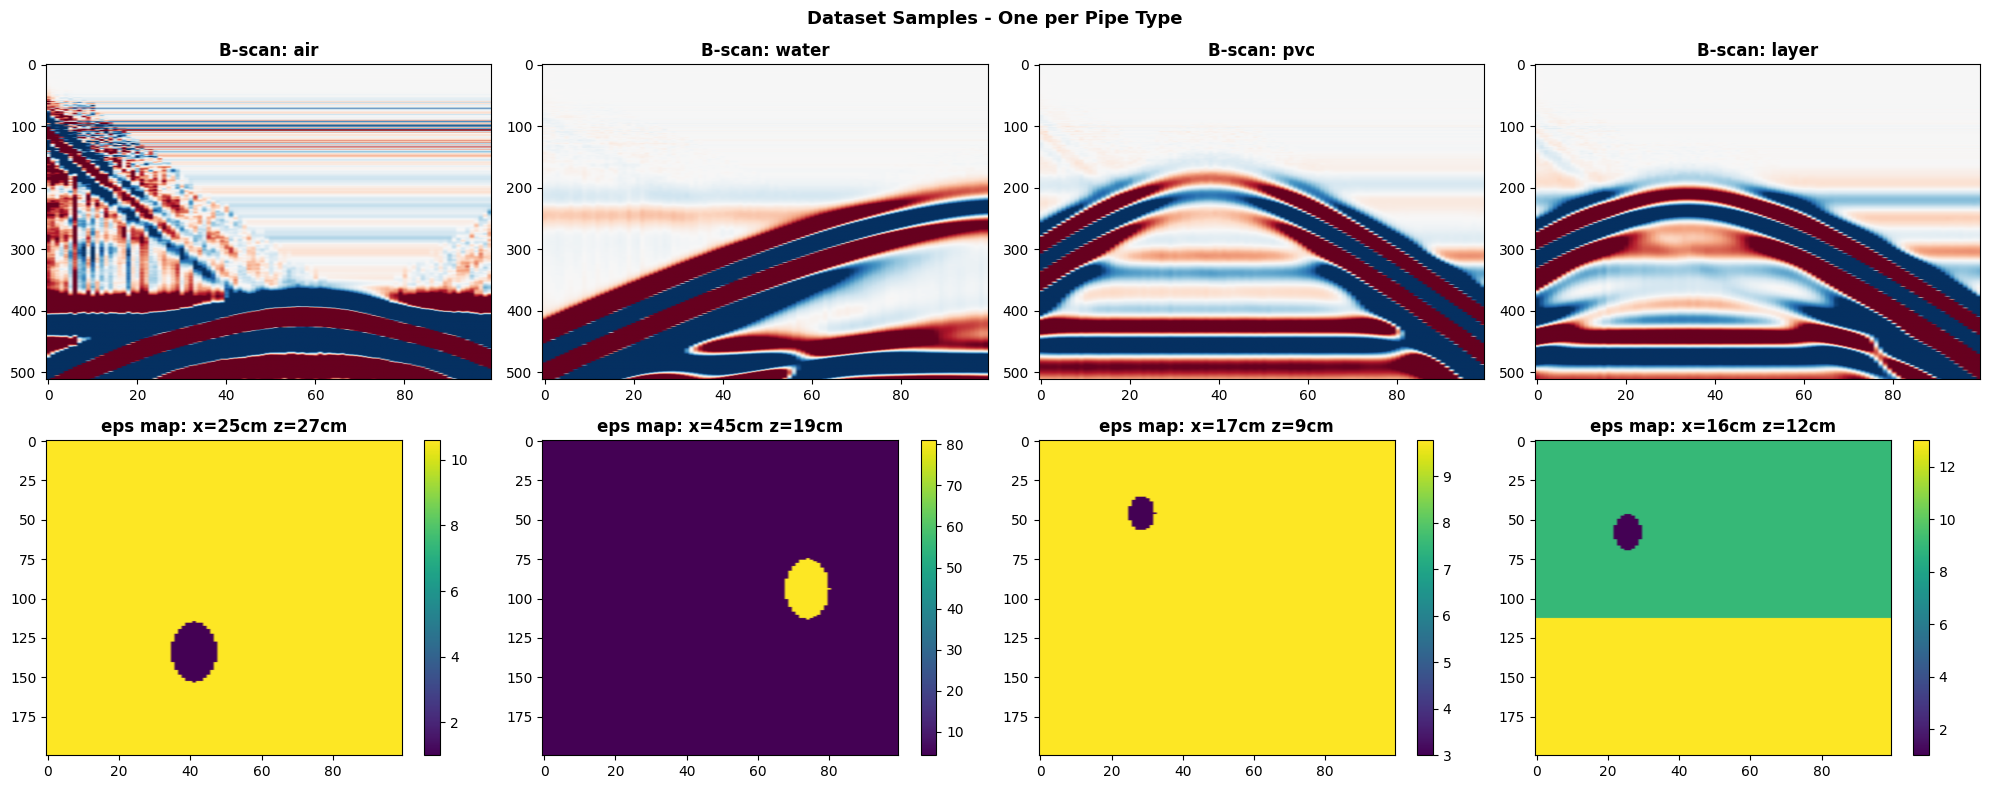

Preview saved to Drive.


In [7]:
import matplotlib.pyplot as plt

type_examples = {}
for i in range(TOTAL_SAMPLES):
    if is_completed(i):
        t = all_params[i]['pipe_type']
        if t not in type_examples:
            type_examples[t] = i
    if len(type_examples) == 4:
        break

n_types = len(type_examples)
if n_types == 0:
    print('No completed samples yet. Run Cell 6 first.')
else:
    fig, axes = plt.subplots(2, n_types, figsize=(5*n_types, 8))
    if n_types == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle('Dataset Samples - One per Pipe Type', fontsize=13, fontweight='bold')
    for col, (pipe_type, sid) in enumerate(type_examples.items()):
        bscan = np.load(f'{BSCAN_DIR}/bscan_{sid:04d}.npy')
        eps   = np.load(f'{EPS_DIR}/eps_{sid:04d}.npy')
        p     = all_params[sid]
        clip  = 0.01 * np.abs(bscan).max()
        axes[0, col].imshow(np.clip(bscan, -clip, clip), aspect='auto', cmap='RdBu')
        axes[0, col].set_title(f'B-scan: {pipe_type}', fontweight='bold')
        im = axes[1, col].imshow(eps, aspect='auto', cmap='viridis')
        axes[1, col].set_title(f'eps map: x={p["pipe_x"]*100:.0f}cm z={p["pipe_z"]*100:.0f}cm',
                               fontweight='bold')
        plt.colorbar(im, ax=axes[1, col])
    plt.tight_layout()
    plt.savefig(f'{DATASET_DIR}/dataset_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Preview saved to Drive.')


## CELL 8 - Final Assembly (run ONLY after all 1000 samples complete)

In [8]:
completed = [i for i in range(TOTAL_SAMPLES) if is_completed(i)]
print(f'Assembling {len(completed)} samples...')
if len(completed) < TOTAL_SAMPLES:
    print(f'WARNING: Only {len(completed)}/{TOTAL_SAMPLES} done. Complete generation first.')
else:
    bscans, eps_maps = [], []
    for i, sid in enumerate(completed):
        bscans.append(np.load(f'{BSCAN_DIR}/bscan_{sid:04d}.npy'))
        eps_maps.append(np.load(f'{EPS_DIR}/eps_{sid:04d}.npy'))
        if (i+1) % 200 == 0:
            print(f'  Loaded {i+1}/{len(completed)}...')
    bscans   = np.array(bscans)
    eps_maps = np.array(eps_maps)
    print(f'B-scans:   {bscans.shape}')
    print(f'Eps maps:  {eps_maps.shape}')
    np.save(f'{DATASET_DIR}/bscans_all.npy', bscans)
    np.save(f'{DATASET_DIR}/eps_maps_all.npy', eps_maps)
    print('Dataset assembled and saved. Ready for FNO training!')


Assembling 1000 samples...
  Loaded 200/1000...
  Loaded 400/1000...
  Loaded 600/1000...
  Loaded 800/1000...
  Loaded 1000/1000...
B-scans:   (1000, 512, 100)
Eps maps:  (1000, 200, 100)
Dataset assembled and saved. Ready for FNO training!
